In [58]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np

In [59]:
# mnist에서 제공한 fashion 예제
(X_train, y_train), (X_test, y_test) = datasets.fashion_mnist.load_data()

# X_train.shape  # 데이터확인


In [60]:
# X_test, y_test를 이용해서 평가를 하고, X_test, y_test 중 16개를 가져와서 예측

# 학습은 1 에포크만 적용(이유 : 시간 때문에)


# 예측을 하면 분류 수만큼 확률이 나옴
# 왜 ? 모델 설계에서 출력층 활성화 함수가 softmax
# 가장 확률이 높은 분류 번호 -> 타이틀(class_names)

class_names = [
  'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt',
  'Sneaker', 'Bag', 'Ankle boot'
]


In [61]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# 콜백

callbacks = [
	# 조기 종료
  EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights =True),
	# 가장 좋았던 성능을 저장 -> 중간에 중지해도 중지전까지 최고 성능을 가져옴
  ModelCheckpoint(filepath='best_cifar10_model.keras', monitor = 'val_accuracy',
                  save_best_only = True, verbose=1),
	# 학습률을 고정값이 아닌 상황에 따라 줄어들도록 조절
	ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience = 3, min_lr=1e-6)

]

In [62]:
# 파이프라인 : 성능 향상 <- 학습 중에 다음 학습 데이터를 준비
from tensorflow.data import Dataset

# 콜백때문에 코드가 늘어남 (검증기준으로)
DATASET_SIZE = 60000
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2) # 검증 사이즈 
dataset = Dataset.from_tensor_slices((X_train, y_train))

# 섞음
dataset = dataset.shuffle(buffer_size = DATASET_SIZE) # buffer_size = 섞을 데이터 수
# 훈련 데이터 셋
train_dataset = dataset.take(TRAIN_SIZE) # TRAIN_SIZE 만큼 가져옴(take)
# 검증 데이터 셋
val_dataset = dataset.skip(TRAIN_SIZE) # TRAIN_SIZE 만큼 제외 (skip)

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [63]:
# 데이터 증강 : 이미지를 돌리거나, 색상 반전등과 같이 변형을 한 복사본을 만들어 학습
# (다양한 형태의 이미지를 준비하지 않아도 생성해서 학습할 수 있도록)

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"), # 좌 우 반전
  tf.keras.layers.RandomRotation(0.2) # 20% 범위 내에서 무작위 회전
])

In [64]:
# 모델 설계

model = tf.keras.models.Sequential([
  tf.keras.Input((28, 28, 1)),
  
	# 데이터 증강 (시간이 오래걸려서 주석처리함)
  # data_augmentation,

  # 정규화 
  tf.keras.layers.Rescaling(1./255),
	
	# 블록 1
  # (N개의 특징을 분석 (필터사이즈, 필터사이즈), 테두리, 활성화함수(웬만하면 relu))
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'), #(N(32)개의 특징을 분석하겠다)
  # BatchNormalization = 한 결과를 다시 정규화 (편차가 1이 되도록 조절)
	tf.keras.layers.BatchNormalization(),
  # 파이프라인을 줄이려고(5,5)효과 2번함 (한번만 해도됨)
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
  # 풀링 : 이미지 크기 줄임
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),

	# 블록 3
	tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.GlobalAveragePooling2D(), # 파라미터 줄이고 안정화 

	# 분류기 : 숫자는 클래스 개수
	tf.keras.layers.Dense(10, activation='softmax'),
  
])

In [65]:
# 모델 설정
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy', # 만약 softmax여도 원핫인코딩이면 categorical_crossentropy
  metrics=['accuracy']
)

In [66]:
# 학습
history = model.fit(
  train_dataset,
  epochs = 5,
  verbose = 1,
  validation_data = val_dataset,
  callbacks = callbacks,
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7163 - loss: 0.8034
Epoch 1: val_accuracy improved from None to 0.35250, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 70s 175ms/step - accuracy: 0.8019 - loss: 0.5545 - val_accuracy: 0.3525 - val_loss: 1.9845 - learning_rate: 0.0010
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8735 - loss: 0.3485
Epoch 2: val_accuracy improved from 0.35250 to 0.87550, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 74s 197ms/step - accuracy: 0.8805 - loss: 0.3319 - val_accuracy: 0.8755 - val_loss: 0.3445 - learning_rate: 0.0010
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8954 - loss: 0.2907
Epoch 3: val_accuracy improved from 0.87550 to 0.89033, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_cif

In [67]:
# 평가
_, acc = model.evaluate(X_test, y_test)
print(f'정확도 : {acc}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9069 - loss: 0.2630
정확도 : 0.9068999886512756


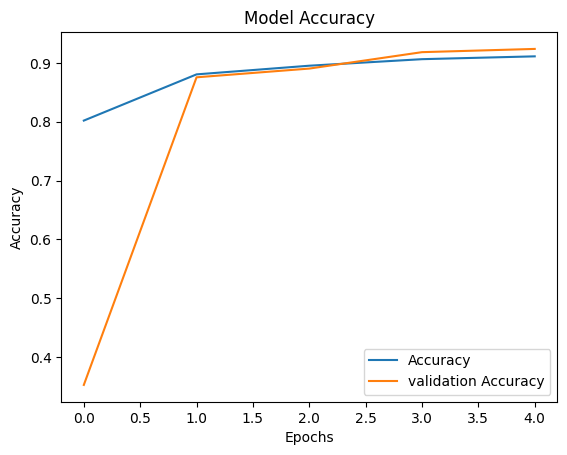

In [68]:
# 성능 시각화 
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


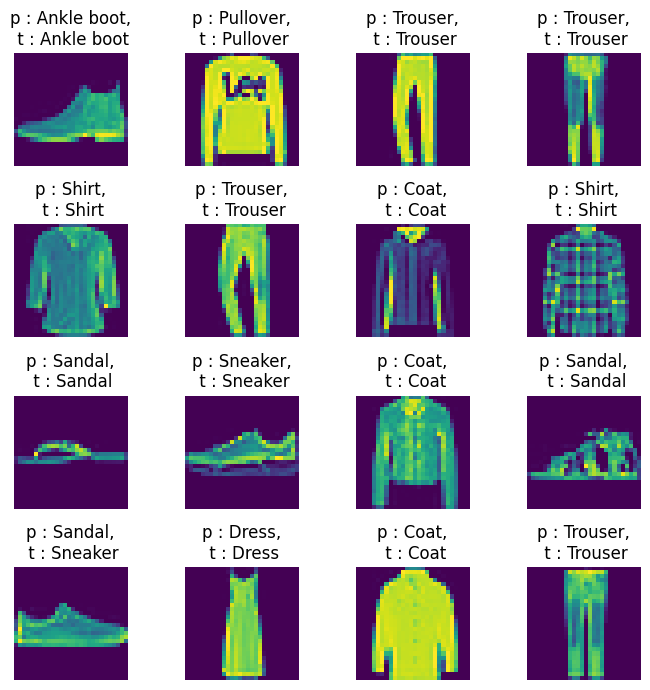

In [69]:
# 이미지 시각화 

predictions = model.predict(X_test[:16]) # 16개 이미지만 불러오기

fig, axes = plt.subplots(4, 4, figsize=(7,7))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_test[i])
  predict_idx = predictions[i].argmax()
  predict_name = class_names[predict_idx]
  real_idx = y_test[i]
  real_name = class_names[real_idx]
  ax.set_title(f"p : {predict_name},\n t : {real_name}")
  ax.axis('off')
plt.tight_layout()
plt.show()